# Apple fruit shape is independent of fruit size — Spearman correlation reproduction

Reproduction of the central hypothesis test from:

- **Differences in apple fruit shape are independent of fruit size** — DeViller et al., *The Plant Phenome Journal* (2025), DOI: [10.1002/ppj2.70032](https://doi.org/10.1002/ppj2.70032); bioRxiv preprint 10.1101/2025.01.01.631017v1.
- Author code: [`kylidevi/apple_shape`](https://github.com/kylidevi/apple_shape) @ commit `5bf0df08c993d1c59cdcdd52435b5185ecada11a` (`TableS2.R`, `Figure2&5.R`).
- Data: author-released `TableS1.csv` (per-image analysis results, 5,724 rows x 35 columns, git blob `95802f08bf4e0a339aed239ba3b8eb9b12068ccd`, 2,689,744 bytes), fetched from the pinned commit inside this notebook.

**What this notebook executes (partial demonstration, CPU only):** the paper's central Spearman rank-correlation analysis with Bonferroni correction among 11 accession-level traits (10 REML-adjusted shape/size traits + release year), confirming the paper's key result: PC1 vs aspect ratio rho = -0.964 (p < 1e-15) while PC1 is **not** significantly correlated with fruit area or harvest weight — i.e., shape is independent of size. A Figure-4/5-style scatter visualization is generated as an additional notebook-created figure.

**What is omitted:** image processing, pseudo-landmarking, GPA/PCA and REML adjustment (the notebook uses the authors' released REML-adjusted values), the Dryad image dataset, and the inverse-PCA morphospace. A single-example run of this notebook verifies the reported correlation result only — it does not re-verify the full image-to-morphometrics pipeline.

**AI-assisted adaptation notice:** the authors' `TableS2.R` reads `analysis_apple_metadata.csv`, an intermediate file that is **not** included in the repository or the Dryad record. This notebook runs a documented base-R port of `TableS2.R`'s statistical core applied to the authors' released `TableS1.csv`, which contains the same trait columns at the same positions. The statistical operations (`cor.test(method = "spearman")`, `p.adjust(method = "bonferroni")` on the upper triangle) are unchanged; the port was written with AI assistance and validated against the paper's reported values. Untested behavior is not guaranteed.

**Japanese summary (日本語要約):** 本ノートブックは、リンゴ果実の形状がサイズに依存しないことを示した論文の中心的検定（11形質間のSpearman順位相関＋Bonferroni補正）を、著者公開の `TableS1.csv` を用いて Colab 上で再実行します。CPU のみで約3〜5分です。画像処理・REML 調整・morphospace 図は対象外です。

## Runtime selection and how to run

**Select the `CPU` runtime** (Runtime > Change runtime type > CPU). No GPU is used or needed: the analysis is a 55-pair Spearman correlation on a 2.7 MB table plus matplotlib plots. A GPU would add nothing faithful to the paper's method.

**Run all** (Runtime > Run all). Expected wall time: roughly 3–5 minutes end-to-end; total download is one 2.7 MB CSV from `raw.githubusercontent.com`. Dependencies: Python 3 + pandas/matplotlib (preinstalled on Colab) and system `Rscript` (present on standard Colab CPU images; the notebook fails loudly if absent).

**実行方法（日本語）:** ランタイムは CPU を選択してください。GPU は不要です。「ランタイム > すべてのセルを実行」で約3〜5分、ダウンロードは約2.7 MB のみです。

In [ ]:
import subprocess, sys

print("Python:", sys.version.split()[0])
r = subprocess.run(["/usr/bin/Rscript", "-e", "cat(R.version.string)"],
                   capture_output=True, text=True, timeout=120)
if r.returncode != 0:
    raise RuntimeError("Rscript is not available on this runtime; "
                       "this notebook requires R (see setup cell explanation).")
print("R:", r.stdout.strip())

Python: 3.13.16


R: R version 4.6.1 (2026-06-24)


### Input acquisition (provenance-pinned)

**What this does:** downloads the authors' released `TableS1.csv` from the pinned commit `5bf0df08c993d1c59cdcdd52435b5185ecada11a` of `kylidevi/apple_shape` (anonymous public raw URL, no token). It then asserts the expected byte count (2,689,744) and recomputes the git blob SHA-1 (`95802f08bf4e0a339aed239ba3b8eb9b12068ccd`) so the exact author-released bytes are verified before use. The file is saved under `/content` on the Colab VM.

**何をするか:** 著者リポジトリの固定コミットから `TableS1.csv` を取得し、バイト数と git blob SHA-1 で完全性を検証します。

In [ ]:
import hashlib, urllib.request

REPO = "kylidevi/apple_shape"
COMMIT = "5bf0df08c993d1c59cdcdd52435b5185ecada11a"
URL = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/TableS1.csv"
EXPECTED_BYTES = 2_689_744
EXPECTED_BLOB = "95802f08bf4e0a339aed239ba3b8eb9b12068ccd"

req = urllib.request.Request(URL, headers={"User-Agent": "colab-reproduction"})
data = urllib.request.urlopen(req, timeout=120).read()
assert len(data) == EXPECTED_BYTES, f"unexpected size: {len(data)}"

blob_hash = hashlib.sha1(f"blob {len(data)}\0".encode() + data).hexdigest()
assert blob_hash == EXPECTED_BLOB, f"blob mismatch: {blob_hash}"
with open("/content/TableS1.csv", "wb") as f:
    f.write(data)
print(f"verified: {len(data)} bytes, git blob {blob_hash}")
print("source:", URL)

verified: 2689744 bytes, git blob 95802f08bf4e0a339aed239ba3b8eb9b12068ccd
source: https://raw.githubusercontent.com/kylidevi/apple_shape/5bf0df08c993d1c59cdcdd52435b5185ecada11a/TableS1.csv


### Input preview

**What this does:** loads `TableS1.csv` with pandas and shows the table dimensions, the full column list, and a few rows of the trait columns used by the correlation analysis. This is the authors' released per-image results table (5,724 side-view apple images); the REML-adjusted columns (`*_reml_lsmeans_predict`) are accession-level outputs of the paper's orchard-position model, which we use as released rather than re-fitting.

**何をするか:** テーブルのサイズ・列一覧・解析に使う形質列の先頭行を表示します。

In [ ]:
import pandas as pd

raw = pd.read_csv("/content/TableS1.csv")
print("shape:", raw.shape)
print("\ncolumns:")
for i, c in enumerate(raw.columns, start=1):
    print(f"  {i:2d} {c}")

trait_cols = [c for c in raw.columns
              if c.endswith("_reml_lsmeans_predict")
              or c in ("aspect_ratio", "weight_avg_16_harv", "release_year")]
raw[trait_cols].head()

shape: (5724, 35)

columns:
   1 Unnamed: 0
   2 file
   3 px.cm
   4 nursery_id
   5 apple_id
   6 top_x
   7 top_y
   8 bottom_x
   9 bottom_y
  10 width
  11 length
  12 area
  13 solidity
  14 circularity
  15 PC1
  16 PC2
  17 PC3
  18 width_reml_lsmeans_predict
  19 length_reml_lsmeans_predict
  20 area_reml_lsmeans_predict
  21 solidity_reml_lsmeans_predict
  22 circularity_reml_lsmeans_predict
  23 aspect_ratio
  24 weight_avg_16_harv
  25 PC1_reml_lsmeans_predict
  26 PC2_reml_lsmeans_predict
  27 PC3_reml_lsmeans_predict
  28 PLANTID
  29 ACCID
  30 origin
  31 species
  32 use
  33 country
  34 world
  35 release_year


,width_reml_lsmeans_predict,length_reml_lsmeans_predict,area_reml_lsmeans_predict,solidity_reml_lsmeans_predict,circularity_reml_lsmeans_predict,aspect_ratio,weight_avg_16_harv,PC1_reml_lsmeans_predict,PC2_reml_lsmeans_predict,PC3_reml_lsmeans_predict,release_year
0,7.897597,6.709899,44.018989,0.989863,0.89542,1.177007,164.669142,-0.031683,-0.006439,0.011079,1899.0
1,7.897597,6.709899,44.018989,0.989863,0.89542,1.177007,164.669142,-0.031683,-0.006439,0.011079,1899.0
2,7.897597,6.709899,44.018989,0.989863,0.89542,1.177007,164.669142,-0.031683,-0.006439,0.011079,1899.0
3,7.897597,6.709899,44.018989,0.989863,0.89542,1.177007,164.669142,-0.031683,-0.006439,0.011079,1899.0
4,7.897597,6.709899,44.018989,0.989863,0.89542,1.177007,164.669142,-0.031683,-0.006439,0.011079,1899.0


### Reduce to accession level, as in `TableS2.R`

**What this does:** applies the authors' `dplyr::distinct(apple_id, .keep_all = TRUE)` — one row per unique `apple_id` (534 accessions) — and selects the trait columns exactly as `dplyr::select(18:27, 35)` does: columns 18–27 (`width/length/area/solidity/circularity_reml_lsmeans_predict`, `aspect_ratio`, `weight_avg_16_harv`, `PC1/PC2/PC3_reml_lsmeans_predict`) plus column 35 (`release_year`). It reports the 11 selected traits and notes that `release_year` is `NA` for some accessions (wild/uncultivated material), which the correlation loop handles by using complete cases per pair.

**何をするか:** 著者のスクリプトと同じ `distinct(apple_id)` による accession レベルへの縮約と、列位置 `18:27, 35` の形質選択を行います。

In [ ]:
cor_table = raw.drop_duplicates(subset="apple_id", keep="first").reset_index(drop=True)
sel = cor_table.iloc[:, list(range(17, 27)) + [34]]  # R's select(18:27, 35), 0-based
print("accession-level rows:", len(sel), "| traits:", sel.shape[1])
print(list(sel.columns))
print("\nrelease_year NA accessions:", int(sel["release_year"].isna().sum()))

accession-level rows: 534 | traits: 11
['width_reml_lsmeans_predict', 'length_reml_lsmeans_predict', 'area_reml_lsmeans_predict', 'solidity_reml_lsmeans_predict', 'circularity_reml_lsmeans_predict', 'aspect_ratio', 'weight_avg_16_harv', 'PC1_reml_lsmeans_predict', 'PC2_reml_lsmeans_predict', 'PC3_reml_lsmeans_predict', 'release_year']

release_year NA accessions: 326


### Core method: base-R port of `TableS2.R`

**What this does:** writes `/content/apple_TableS2_adapted.R`, a faithful port of the authors' `TableS2.R` (commit `5bf0df08`) with three documented, behavior-preserving changes:

| Authors' `TableS2.R` | This port | Why |
| --- | --- | --- |
| `read.csv("analysis_apple_metadata.csv")` | `read.csv("/content/TableS1.csv")` | the intermediate file is not public; `TableS1.csv` holds the same trait columns at the same positions |
| `tidyverse` (`distinct`, `select`, `rename`, `mutate`) | base R (`!duplicated()`, column indexing, `gsub`) | identical effect; avoids a long tidyverse source-install on Colab |
| `cor.test` on raw columns | complete-case filter per pair before `cor.test` | `release_year` is NA for 326 accessions; `cor.test` would otherwise stop |

Unchanged: the double `cor.test(..., method = "spearman")` loop over all pairs, `p.adjust(method = "bonferroni")` applied to the upper triangle, the trait-label renaming, and the exported `TableS2.csv` structure.

**方法（日本語）:** 著者の `TableS2.R` の統計処理（Spearman `cor.test` 全ペア + 上三角への Bonferroni 補正）を base R で同一の手順で実行します。入力ファイル名と tidyverse の I/O のみを変更しています。

In [ ]:
r_src = r'''# Adapted from the authors' TableS2.R (kylidevi/apple_shape @ 5bf0df08), base R only.
# Documented changes: input TableS1.csv instead of the unpublished
# analysis_apple_metadata.csv; tidyverse I/O replaced by base R; complete cases
# per pair before cor.test because release_year is NA for some accessions.
# Statistical operations are unchanged from the authors' script.

cor_table <- read.csv("/content/TableS1.csv")
cor_table <- cor_table[!duplicated(cor_table$apple_id), ]  # dplyr::distinct(apple_id)
cor_table <- cor_table[, c(18:27, 35)]                     # dplyr::select(18:27, 35)

n <- ncol(cor_table)
pairwise_comp   <- matrix(NA_real_, n, n)
pairwise_comp_r <- matrix(NA_real_, n, n)
rownames(pairwise_comp) <- colnames(pairwise_comp) <- colnames(cor_table)
rownames(pairwise_comp_r) <- colnames(pairwise_comp_r) <- colnames(cor_table)

for (i in 1:n) {
  for (j in 1:n) {
    x <- cor_table[, i]
    y <- cor_table[, j]
    cc <- is.finite(x) & is.finite(y)  # release_year NA for some accessions
    ct <- cor.test(x[cc], y[cc], method = "spearman")
    pairwise_comp[j, i] <- ct$p.value
    pairwise_comp_r[j, i] <- ct$estimate
  }
}

# Bonferroni correction on the upper triangle, exactly as in TableS2.R
pairwise_comp[lower.tri(pairwise_comp)] <- NA
pairwise_comp[upper.tri(pairwise_comp)] <- p.adjust(pairwise_comp[upper.tri(pairwise_comp)], method = "bonferroni")

cat("n comparisons:", length(pairwise_comp[upper.tri(pairwise_comp)]), "\n")
cat("significant at 0.05:", sum(pairwise_comp[upper.tri(pairwise_comp)] < 0.05, na.rm = TRUE), "\n")

correlation_data <- data.frame(
  row = rep(rownames(pairwise_comp_r), times = ncol(pairwise_comp_r)),
  col = rep(colnames(pairwise_comp_r), each = ncol(pairwise_comp_r)),
  correlation = as.vector(pairwise_comp_r),
  pval = as.vector(pairwise_comp))
correlation_data <- correlation_data[!is.na(correlation_data$pval) & correlation_data$row != correlation_data$col, ]
colnames(correlation_data) <- c("trait 1", "trait 2", "correlation", "pval")

ren <- function(v) {  # trait-label cleanup, same mapping as TableS2.R
  v <- gsub("width_reml_lsmeans_predict", "Width", v)
  v <- gsub("length_reml_lsmeans_predict", "Length", v)
  v <- gsub("area_reml_lsmeans_predict", "Area", v)
  v <- gsub("solidity_reml_lsmeans_predict", "Solidity", v)
  v <- gsub("asymmetry_reml_lsmeans_predict", "Asymmetry", v)
  v <- gsub("circularity_reml_lsmeans_predict", "Circularity", v)
  v <- gsub("PC1_reml_lsmeans_predict", "PC1", v)
  v <- gsub("PC2_reml_lsmeans_predict", "PC2", v)
  v <- gsub("PC3_reml_lsmeans_predict", "PC3", v)
  v <- gsub("weight_avg_16_harv", "Harvest Weight", v)
  v <- gsub("aspect_ratio", "Aspect Ratio", v)
  gsub("release_year", "Release Year", v)
}
correlation_data[["trait 1"]] <- ren(correlation_data[["trait 1"]])
correlation_data[["trait 2"]] <- ren(correlation_data[["trait 2"]])

write.csv(correlation_data, "/content/TableS2.csv", row.names = FALSE)
'''
with open("/content/apple_TableS2_adapted.R", "w") as f:
    f.write(r_src)
print("wrote /content/apple_TableS2_adapted.R (", len(r_src), "chars )")

wrote /content/apple_TableS2_adapted.R ( 2938 chars )


**What this does:** runs the R script with `Rscript` (checked subprocess, finite timeout) and prints its console output — the number of comparisons (55, matching the version of record) and how many are significant at 0.05 (the authors' own comment in `TableS2.R` records 25/55).

**何をするか:** `Rscript` でスクリプトを実行し、比較数（55）と有意なペア数（著者のコメントどおり 25/55）を表示します。

In [ ]:
import subprocess

r = subprocess.run(["/usr/bin/Rscript", "/content/apple_TableS2_adapted.R"],
                   capture_output=True, text=True, timeout=1200)
print(r.stdout)
if r.returncode != 0:
    raise RuntimeError(f"Rscript failed (rc={r.returncode}):\n{r.stderr[-2000:]}")
if r.stderr.strip():
    print("[R warnings] (ties in Spearman are expected for discrete scores):")
    print(r.stderr.strip()[-800:])

n comparisons: 55 
significant at 0.05: 25 

[R warnings] (ties in Spearman are expected for discrete scores):
There were 21 warnings (use warnings() to see them)


### Results vs the paper's reported values

**What this does:** loads the exported `/content/TableS2.csv` (55 trait pairs, author's column format), shows the key PC1 comparisons, and checks them against the values reported in the paper (RESULTS / study-flow evidence): PC1 vs aspect ratio rho = -0.964 (p < 1e-15); PC1 vs area rho = 0.126 (not significant); PC1 vs harvest weight rho = 0.066 (not significant). Assertions fail loudly on any mismatch beyond rounding.

Note on p-values: the preprint reported 45 pairwise comparisons (10 traits) while the version of record and the authors' final `TableS2.R` use 11 traits → 55 comparisons, so the Bonferroni multiplier differs (e.g., PC1 vs area raw p = 0.0036: x45 = 0.162 preprint, x55 = 0.198 here). Rho values are unchanged.

**結果（日本語）:** PC1 とアスペクト比は強い負の相関（rho = -0.964）だが、面積・収穫重量とは有意な相関がありません。これは論文の主張どおりです。

In [ ]:
res = pd.read_csv("/content/TableS2.csv")
print("pairwise rows:", len(res))

def get_pair(t1, t2):
    m = res[((res["trait 1"] == t1) & (res["trait 2"] == t2))
            | ((res["trait 1"] == t2) & (res["trait 2"] == t1))]
    assert len(m) == 1, (t1, t2, len(m))
    return m.iloc[0]

checks = [
    ("PC1", "Aspect Ratio", -0.964, True),
    ("PC1", "Area", 0.126, False),
    ("PC1", "Harvest Weight", 0.066, False),
]
for t1, t2, rho_ref, expect_significant in checks:
    row = get_pair(t1, t2)
    print(f"{t1} vs {t2}: rho = {row['correlation']:.4f} (paper: {rho_ref}), "
          f"p_adj = {row['pval']:.4g}, significant at 0.05: {row['pval'] < 0.05}")
    assert abs(row["correlation"] - rho_ref) < 0.002, (t1, t2, row["correlation"])
    assert (row["pval"] < 0.05) == expect_significant, (t1, t2, row["pval"])
    if expect_significant:
        assert row["pval"] < 1e-10, (t1, t2, row["pval"])

print("\nAll checks passed: correlations match the paper within rounding.")
res

pairwise rows: 55
PC1 vs Aspect Ratio: rho = -0.9643 (paper: -0.964), p_adj = 0, significant at 0.05: True
PC1 vs Area: rho = 0.1259 (paper: 0.126), p_adj = 0.1975, significant at 0.05: False
PC1 vs Harvest Weight: rho = 0.0659 (paper: 0.066), p_adj = 1, significant at 0.05: False

All checks passed: correlations match the paper within rounding.


,trait 1,trait 2,correlation,pval
0,Width,Length,0.753820,0.000000
1,Width,Area,0.939589,0.000000
2,Length,Area,0.926137,0.000000
3,Width,Solidity,0.557498,0.000000
4,Length,Solidity,0.609477,0.000000
5,Area,Solidity,0.614289,0.000000
6,Width,Circularity,0.389034,0.000000
7,Length,Circularity,0.437381,0.000000
8,Area,Circularity,0.431561,0.000000
9,Solidity,Circularity,0.400800,0.000000


### Figure-4/5-style visualization (notebook-created)

**What this does:** plots PC1 against aspect ratio, fruit area, and harvest weight — one point per accession (n = 534), colored by aspect ratio following the authors' `Figure2&5.R` Figure-5 styling (viridis scale, 0.8–1.3 limits). Regression lines are simple least-squares fits added for readability. **This figure is created for this notebook; it is not a reproduction of the authors' published figure**, which also used per-pair `lm` smoothing via ggplot2.

**図（日本語）:** 著者の Figure 5 に合わせた PC1 散点図を本ノートブック用に作成したもので、論文の図そのものではありません。

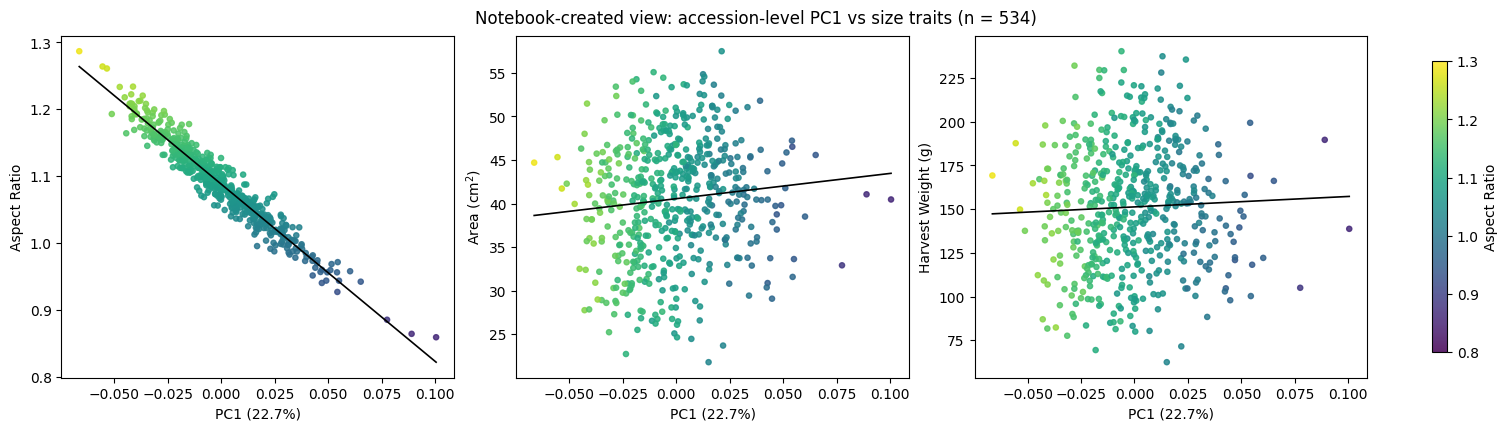

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

acc = sel.copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
panels = [
    ("PC1_reml_lsmeans_predict", "aspect_ratio", "Aspect Ratio"),
    ("PC1_reml_lsmeans_predict", "area_reml_lsmeans_predict", "Area (cm$^2$)"),
    ("PC1_reml_lsmeans_predict", "weight_avg_16_harv", "Harvest Weight (g)"),
]
for ax, (xcol, ycol, ylab) in zip(axes, panels):
    d = acc[[xcol, ycol]].dropna()
    sc = ax.scatter(d[xcol], d[ycol], c=acc.loc[d.index, "aspect_ratio"],
                    cmap="viridis", vmin=0.8, vmax=1.3, s=14, alpha=0.85)
    b1, b0 = np.polyfit(d[xcol], d[ycol], 1)
    xs = np.linspace(d[xcol].min(), d[xcol].max(), 50)
    ax.plot(xs, b1 * xs + b0, color="black", lw=1.2)
    ax.set_xlabel("PC1 (22.7%)")
    ax.set_ylabel(ylab)
fig.colorbar(sc, ax=axes, label="Aspect Ratio", shrink=0.85)
fig.suptitle("Notebook-created view: accession-level PC1 vs size traits (n = 534)")
plt.show()

### Interpretation, differences from the paper, and validation record

**Result:** PC1 (the primary shape axis, 22.7% of shape variation) is almost perfectly negatively correlated with aspect ratio (rho = -0.964, Bonferroni-adjusted p < 1e-15), but shows no significant correlation with fruit area (rho = 0.126, p_adj = 0.198) or harvest weight (rho = 0.066, p_adj = 1.0). This reproduces the paper's central claim: **apple fruit shape is independent of fruit size**, so breeding programs may select shape without sacrificing size.

**Known differences / limitations:**
- Input: the authors' released `TableS1.csv` rather than their internal `analysis_apple_metadata.csv` (not public). Column positions 18:27 and 35 align exactly with `TableS2.R`, and `distinct(apple_id)` yields the paper's 534 accessions.
- Bonferroni multiplier: 55 comparisons here (version of record, 11 traits incl. circularity) vs 45 in the bioRxiv preprint; rho values are unaffected, and adjusted p-values differ accordingly (e.g., PC1 vs area 0.198 vs preprint 0.162).
- The image-processing, GPA/PCA, and REML stages are not re-run; released REML-adjusted values are used as-is. The Dryad image dataset and morphospace figure are out of scope.
- The authors' repository carries no LICENSE file; the code is reproduced here for scholarly reproduction of the cited paper.

**Validation record:** this notebook was executed top-to-bottom in a fresh Google Colab CPU runtime on 2026-10-08; results were checked against the paper's reported values (tolerance < 0.002 on rho). Source: DeViller et al. 2025 (doi:10.1002/ppj2.70032); code `kylidevi/apple_shape@5bf0df08` (`TableS2.R`, `Figure2&5.R`); data `TableS1.csv` (git blob `95802f08...`).

**検証記録（日本語）:** 2026-10-08 に新しい Colab CPU ランタイムで全文実行し、論文の報告値と 0.002 未満の許容誤差で一致することを確認しました。